=== DATASET TRAINING ===
  Kehadiran    Tugas   Ujian Status
0     Rajin  Lengkap  Tinggi  Lulus
1     Rajin  Lengkap  Sedang  Lulus
2     Rajin    Tidak  Rendah  Tidak
3    Jarang  Lengkap  Rendah  Tidak
4    Jarang    Tidak  Rendah  Tidak
5     Rajin  Lengkap  Tinggi  Lulus
6    Jarang  Lengkap  Sedang  Tidak
7     Rajin    Tidak  Sedang  Lulus

=== AKURASI MODEL ===
Accuracy : 1.0


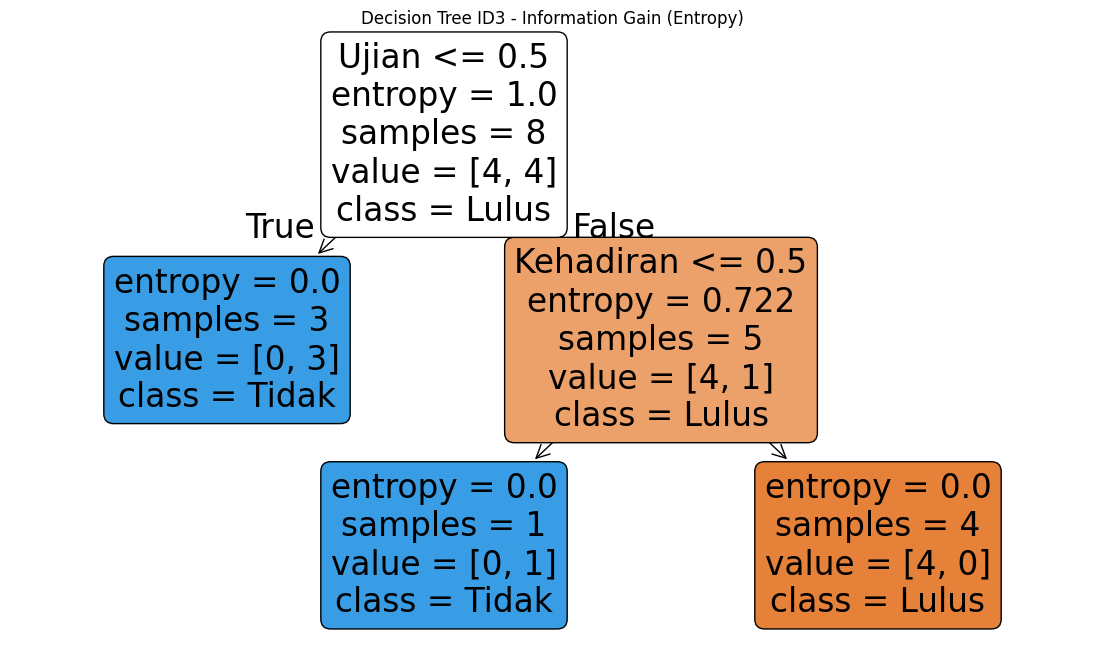


=== FEATURE IMPORTANCE ===
       Fitur  Importance
2      Ujian    0.548795
0  Kehadiran    0.451205
1      Tugas    0.000000

=== HASIL PREDIKSI ===
Prediksi : Lulus


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
# =========================================================
# DECISION TREE - ID3 (INFORMATION GAIN / ENTROPY)
# =========================================================

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# =========================================================
# DATASET
# =========================================================

data = {
    'Kehadiran': ['Rajin', 'Rajin', 'Rajin', 'Jarang',
                  'Jarang', 'Rajin', 'Jarang', 'Rajin'],

    'Tugas': ['Lengkap', 'Lengkap', 'Tidak', 'Lengkap',
              'Tidak', 'Lengkap', 'Lengkap', 'Tidak'],

    'Ujian': ['Tinggi', 'Sedang', 'Rendah', 'Rendah',
              'Rendah', 'Tinggi', 'Sedang', 'Sedang'],

    'Status': ['Lulus', 'Lulus', 'Tidak', 'Tidak',
               'Tidak', 'Lulus', 'Tidak', 'Lulus']
}

df = pd.DataFrame(data)

print("=== DATASET TRAINING ===")
print(df)

# =========================================================
# ENCODING DATA KATEGORIK
# =========================================================

le_kehadiran = LabelEncoder()
le_tugas = LabelEncoder()
le_ujian = LabelEncoder()
le_status = LabelEncoder()

df['Kehadiran'] = le_kehadiran.fit_transform(df['Kehadiran'])
df['Tugas'] = le_tugas.fit_transform(df['Tugas'])
df['Ujian'] = le_ujian.fit_transform(df['Ujian'])
df['Status'] = le_status.fit_transform(df['Status'])

# =========================================================
# FITUR DAN TARGET
# =========================================================

X = df[['Kehadiran', 'Tugas', 'Ujian']]
y = df['Status']

# =========================================================
# MODEL ID3 (ENTROPY / INFORMATION GAIN)
# =========================================================

model_id3 = DecisionTreeClassifier(
    criterion='entropy',   # menggunakan entropy
    random_state=42
)

model_id3.fit(X, y)

# =========================================================
# AKURASI MODEL
# =========================================================

accuracy = model_id3.score(X, y)

print("\n=== AKURASI MODEL ===")
print("Accuracy :", accuracy)

# =========================================================
# VISUALISASI TREE
# =========================================================

plt.figure(figsize=(14,8))

plot_tree(
    model_id3,
    feature_names=['Kehadiran', 'Tugas', 'Ujian'],
    class_names=le_status.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree ID3 - Information Gain (Entropy)")
plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = model_id3.feature_importances_

fitur = pd.DataFrame({
    'Fitur': ['Kehadiran', 'Tugas', 'Ujian'],
    'Importance': importance
})

print("\n=== FEATURE IMPORTANCE ===")
print(fitur.sort_values(by='Importance', ascending=False))

# =========================================================
# PREDIKSI DATA BARU
# =========================================================

# Data Baru:
# Kehadiran = Rajin
# Tugas = Lengkap
# Ujian = Tinggi

sample = [[
    le_kehadiran.transform(['Rajin'])[0],
    le_tugas.transform(['Lengkap'])[0],
    le_ujian.transform(['Tinggi'])[0]
]]

prediksi = model_id3.predict(sample)

print("\n=== HASIL PREDIKSI ===")
print("Prediksi :", le_status.inverse_transform(prediksi)[0])